# Bài 1. Dự báo giá nhà bằng hồi quy tuyến tính, sử dụng Jupyter NoteBook.
- Cho dữ liệu: Housing.csv (nguồn Kaggle)
- Dưới đây là mô tả sơ lược ý nghĩa các thuộc tính của dữ liệu:
o Avg. Area Income: Thu nhập trung bình tại khu vực ngôi nhà đã bán
o Avg. Area House Age: Trung bình tuổi của một ngôi nhà đã bán
o Avg. Area Number of Rooms: Trung bình diện tích các phòng
o Avg. Area Number of Bedrooms: Trung bình diện tích phòng ngủ
o Area Population: Dân số tại khu vực bán nhà
o Price: Giá ngôi nhà đã bán
o Address: Địa chỉ ngôi nhà bán
- Yêu cầu:
o Xây dựng mô hình máy học để dự báo giá nhà, sử dụng Linear Regression
o Đánh giá chất lượng mô hình
o Bổ sung các Chart phù hợp để hỗ trợ cho việc phân tích dữ liệu
o Xuất mô hình ra ổ cứng và tái sử dụng mô hình thay vì phải training lại.
o Sử dụng nền tảng Jupyter Notebook để lập trình.


## 1. Import Thư viện
Trong bước này, chúng ta gọi các công cụ cần thiết:
* **Pandas & Numpy:** Xử lý và tính toán dữ liệu.
* **Matplotlib & Seaborn:** Vẽ biểu đồ trực quan.
* **Scikit-learn:** Thư viện chứa mô hình Hồi quy tuyến tính, chia dữ liệu và các hàm đánh giá.
* **Joblib:** Để lưu và tải lại mô hình.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import joblib

# Cài đặt phong cách biểu đồ mặc định
sns.set_style('whitegrid')

## 2. Tải Dữ Liệu
Thay vì dùng file nội bộ, ta sẽ đọc file csv trực tiếp từ một đường link raw trên Github chứa tập dữ liệu USA Housing chuẩn của Kaggle.

In [3]:
# Đường link chứa dữ liệu Housing
url = "https://raw.githubusercontent.com/PraveenObulreddy/USA-Housing-Price-Prediction/refs/heads/main/USA_Housing.csv"

# Đọc dữ liệu vào DataFrame
df = pd.read_csv(url)

# Hiển thị 5 dòng đầu tiên để kiểm tra
display(df.head())

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


## 3. Khám phá dữ liệu (Exploratory Data Analysis - EDA)
Để mô hình hoạt động tốt, chúng ta cần hiểu dữ liệu. 
Chúng ta sẽ vẽ 2 biểu đồ:
1. **Biểu đồ phân phối của Giá nhà (Price):** Xem giá nhà tập trung ở khoảng nào.
2. **Biểu đồ Tương quan (Heatmap):** Xem thuộc tính nào (như Thu nhập hay Tuổi của nhà) ảnh hưởng mạnh nhất đến giá nhà.

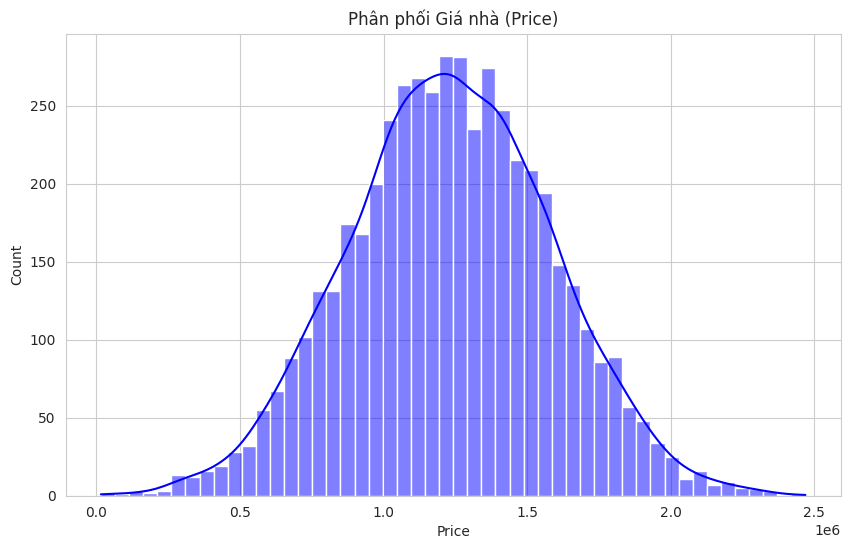

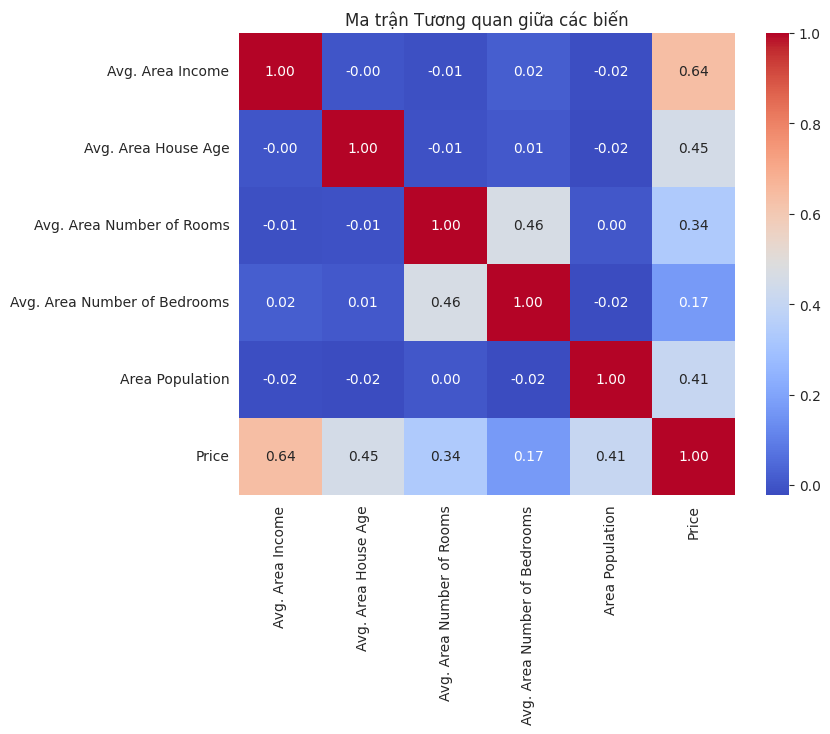

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, bins=50, color='blue')
plt.title('Phân phối Giá nhà (Price)')
plt.show()

plt.figure(figsize=(8, 6))
# Tính toán ma trận tương quan (chỉ tính trên các cột số)
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận Tương quan giữa các biến')
plt.show()

## 4. Chuẩn bị dữ liệu (Data Preprocessing)
* **Biến X (Đặc trưng - Features):** Chứa các thông tin dùng để dự báo. Ta sẽ bỏ cột 'Price' (vì đây là kết quả cần tìm) và cột 'Address' (vì là dạng chuỗi văn bản).
* **Biến y (Nhãn - Target):** Cột 'Price' - Giá trị mà chúng ta muốn máy học dự báo.
* Sau đó, chia dữ liệu thành 2 tập: Tập huấn luyện (Training set - 70%) và tập kiểm tra (Testing set - 30%).

In [5]:
# Tách biến X và y
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 
        'Avg. Area Number of Bedrooms', 'Area Population']]
y = df['Price']

# Chia dữ liệu: 70% để học, 30% để kiểm tra lại
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Số lượng dữ liệu huấn luyện: {X_train.shape[0]} dòng")
print(f"Số lượng dữ liệu kiểm tra: {X_test.shape[0]} dòng")

Số lượng dữ liệu huấn luyện: 3500 dòng
Số lượng dữ liệu kiểm tra: 1500 dòng


## 5. Xây dựng và Huấn luyện Mô hình
Khởi tạo mô hình `LinearRegression` và cho máy học các mẫu dữ liệu từ tập huấn luyện (`X_train` và `y_train`).

In [6]:
# Khởi tạo mô hình
lm = LinearRegression()

# Huấn luyện (fit) mô hình với dữ liệu
lm.fit(X_train, y_train)

# In ra các hệ số của phương trình tuyến tính
print("Hệ số chặn (Intercept):", lm.intercept_)
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Hệ số (Coefficient)'])
display(coeff_df)

Hệ số chặn (Intercept): -2638673.4261902785


,Hệ số (Coefficient)
Avg. Area Income,21.625799
Avg. Area House Age,165590.392746
Avg. Area Number of Rooms,119827.783390
Avg. Area Number of Bedrooms,2361.095262
Area Population,15.216581


## 6. Dự báo và Đánh giá
Sau khi máy đã học xong, ta dùng tập kiểm tra `X_test` để đưa cho máy dự đoán.
Để xem máy dự đoán tốt không, ta dùng:
* **Scatter Plot (Biểu đồ phân tán):** Nếu các điểm càng bám sát một đường chéo thẳng, nghĩa là giá dự đoán càng gần với giá thực tế.
* **Các chỉ số sai số:** MAE (Sai số tuyệt đối trung bình), RMSE (Căn bậc hai sai số toàn phương trung bình), và $R^2$ (Hệ số xác định - càng gần 1 càng tốt).

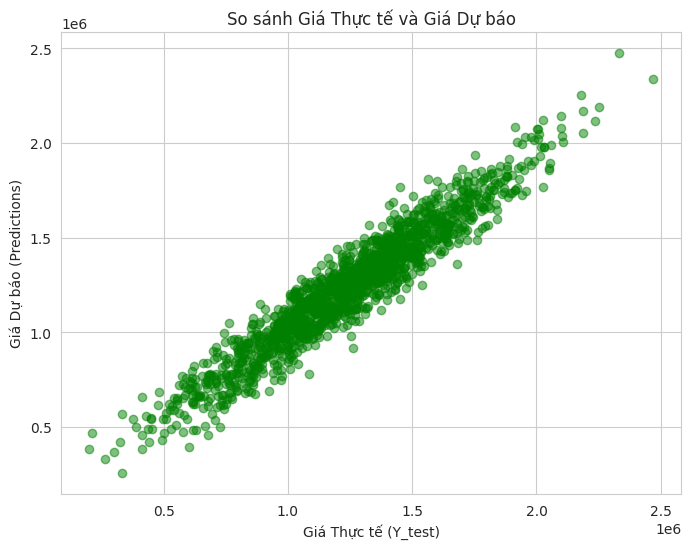

MAE: 81135.5660933687
MSE: 10068422551.400827
RMSE: 100341.5295448541
R-squared: 0.914681849875402


In [7]:
# Dự báo trên tập kiểm tra
predictions = lm.predict(X_test)

# Vẽ biểu đồ so sánh giá trị thực tế và giá trị dự báo
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='green')
plt.xlabel('Giá Thực tế (Y_test)')
plt.ylabel('Giá Dự báo (Predictions)')
plt.title('So sánh Giá Thực tế và Giá Dự báo')
plt.show()

# Đánh giá bằng các chỉ số
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('R-squared:', metrics.r2_score(y_test, predictions))

## 7. Xuất và Tái sử dụng mô hình
Việc huấn luyện mô hình có thể tốn nhiều thời gian và tài nguyên đối với dữ liệu lớn. 
Chúng ta sẽ lưu mô hình thành file `linear_regression_model.pkl`. 
Sau đó, ta giả lập việc load lại mô hình từ file này và thử dự báo một căn nhà mới.

In [8]:
# --- XUẤT MÔ HÌNH ---
model_filename = 'linear_regression_model.pkl'
joblib.dump(lm, model_filename)
print(f"Đã lưu mô hình thành công vào file: {model_filename}")

# --- TÁI SỬ DỤNG MÔ HÌNH ---
# Giả sử bạn mở một file code mới vào ngày hôm sau, bạn chỉ cần load lại:
loaded_model = joblib.load(model_filename)

# Tạo dữ liệu cho 1 căn nhà mới để test (gồm 5 thông số theo đúng thứ tự X)
# Thu nhập: 80000, Tuổi nhà: 6, Số phòng: 7, Số phòng ngủ: 4, Dân số: 30000
new_house_data = np.array([[80000, 6, 7, 4, 30000]])

# Dự báo giá cho căn nhà mới bằng mô hình đã load
predicted_price = loaded_model.predict(new_house_data)
print(f"Dự báo giá cho căn nhà mới là: ${predicted_price[0]:,.2f}")

Đã lưu mô hình thành công vào file: linear_regression_model.pkl
Dự báo giá cho căn nhà mới là: $1,389,669.15


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
